# ICMC Colab Notebook
This is a specially written Google Colab notebook that you can use to write and save code.  
To get started, follow the steps below.

## 1. Make a copy of this notebook in Google Drive

You only need to do this once. You can open your notebook from Drive at any time.

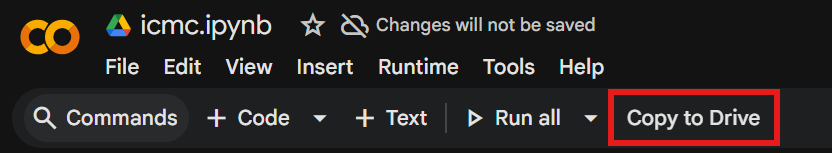

## 2. Click the run button to start the code editor

You will basically need to do this step every day because the editor shuts down after a while.  
If a problem occurs, reach out to an instructor for help or switch to using Binder.

In [ ]:
# <-- Click the run button

_exit_code = 1
!curl -fsSL 'https://raw.githubusercontent.com/ObjectOops/icmc/refs/heads/dev/colab/code.sh' | sh

if _exit_code:
  print(f"Failed with status code: {_exit_code}")
else:
  from google.colab import output
  proxy_url = output.eval_js("google.colab.kernel.proxyPort(3000)")
  print(f"{proxy_url}/?folder=/content/icmc/workbench")

## 3. Click the link when it appears

Next, follow the same steps as the Binder setup.

## Saving Files

Run the cell below to copy Java and Python files to your notebook.  
You must do this to save your files. Otherwise, they will be lost when the editor shuts down.  
You may delete older saves to clean up your notebook.  
The Zip file saving instructions from Binder also work here.

In [ ]:
# <-- Click to save
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import shlex

root = Path.cwd()
files = sorted([p for p in root.rglob("./icmc/workbench/**/*") if p.is_file() and p.suffix.lower() in {".py", ".java"}])
timestamp = datetime.now(ZoneInfo("America/Chicago")).strftime("%Y-%m-%d %H:%M:%S")

parts = ["# <-- Click to load into editor", f"# Generated {timestamp}", "%%bash", "set -e"]
for path in files:
    relpath = path.relative_to(root).as_posix()
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        contents = f.read()
    parts += [f"mkdir -p {shlex.quote(str(Path(relpath).parent))}", f"cat > {shlex.quote(relpath)} << '__EOF__'", contents, "__EOF__"]
get_ipython().set_next_input("\n".join(parts), replace=False)

# Maintainance

You can ignore everything below this message.

In [ ]:
!OPENVSCODE_SERVER_VERSION="1.109.5" \
&& OVSCS_PATH="openvscode-server-v${OPENVSCODE_SERVER_VERSION}-linux-x64" \
&& wget -q -nc "https://github.com/gitpod-io/openvscode-server/releases/download/openvscode-server-v${OPENVSCODE_SERVER_VERSION}/${OVSCS_PATH}.tar.gz" \
&& tar -xzf ${OVSCS_PATH}.tar.gz
# openvscode-server --host 0.0.0.0 --port 8080 --without-connection-token

In [ ]:
!CODE_SERVER_VERSION="4.129.0" \
&& CODE_SERVER_PATH="code-server-${CODE_SERVER_VERSION}-linux-amd64" \
&& wget -q -nc "https://github.com/coder/code-server/releases/download/v${CODE_SERVER_VERSION}/${CODE_SERVER_PATH}.tar.gz" \
&& tar -xzf ${CODE_SERVER_PATH}.tar.gz
# code-server --help

In [ ]:
from google.colab import output
# output.serve_kernel_port_as_window(8080, skip_warning=True)
proxy_url = output.eval_js("google.colab.kernel.proxyPort(8080)")
print(f"{proxy_url}/?folder=/content")